DATASET OVERVIEW
Total Samples  : 150
Total Features : 4
Classes        : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Dataset Info:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000

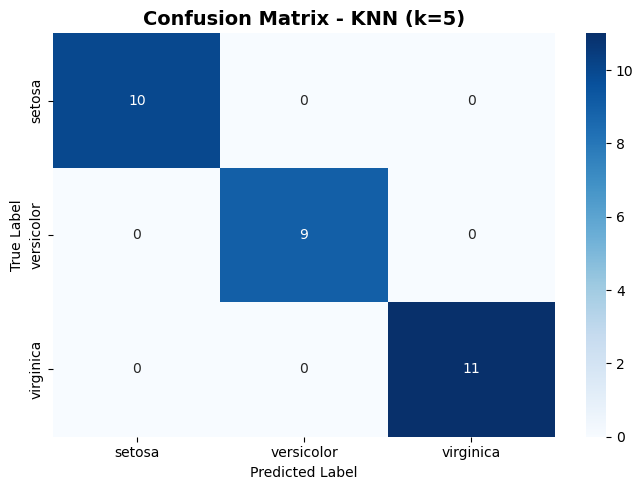

Confusion matrix saved as 'confusion_matrix.png'

FINAL RESULTS
F1 Score (Weighted) : 1.0000
Accuracy            : 100.00%

DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



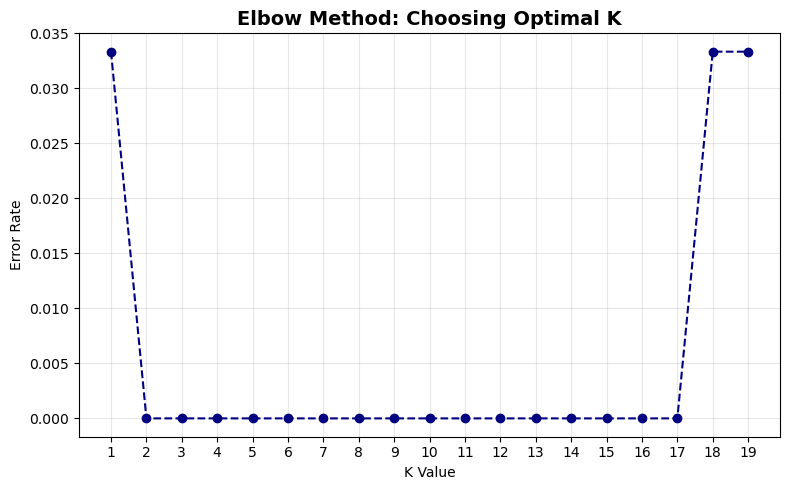

Elbow curve saved as 'elbow_curve.png'


In [6]:
# Project 2: Data Classification Using AI
# Algorithm: K-Nearest Neighbors (KNN)
# Dataset: Iris (built-in from sklearn)

# Step 1: Import libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


# STEP 2: Load and understand the Dataset

iris = load_iris()

# Separate features X and labels Y
X = iris.data       # 4 features: sepal length, sepal width, petal length, petal width
y = iris.target     # 3 classes: 0=Setosa, 1=Versicolor, 2=Virginica

# Convert Dataset to DataFrame
df = pd.DataFrame(X, columns=iris.feature_names)
df['Species'] = [iris.target_names[i] for i in y]

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total Samples  : {X.shape[0]}")
print(f"Total Features : {X.shape[1]}")
print(f"Classes        : {list(iris.target_names)}")
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.describe())


# STEP 3: Feature Scaling (StandardScaler)

# KNN calculate ddistance therefore scalling is important
# Otherwise, larger values dominate smaller values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n" + "=" * 50)
print("FEATURE SCALING DONE")
print("Before scaling (first row):", X[0])
print("After scaling  (first row):", X_scaled[0].round(4))


# STEP 4: Train-Test Split (80% / 20%)

# shuffle=True: to remove order bias
# random_state=42: to get reproducible results

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("\n" + "=" * 50)
print("TRAIN-TEST SPLIT")
print("=" * 50)
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")


# STEP 5: KNN MODEL - Instantiate, Fit, Predict

# using k=5 

model = KNeighborsClassifier(n_neighbors=5)

# Fit:Train model on Training data
model.fit(X_train, y_train)

# Predict: test model on test data
predictions = model.predict(X_test)

print("\n" + "=" * 50)
print("MODEL TRAINED SUCCESSFULLY (KNN, k=5)")
print("=" * 50)


# STEP 6: Output - Confusion Matrix + F1 Score

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)

print("\nCONFUSION MATRIX:")
print(cm)

# Visual confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - KNN (k=5)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved as 'confusion_matrix.png'")

# F1 Score
# weighted: Handles class imbalance
f1 = f1_score(y_test, predictions, average='weighted')

print("\n" + "=" * 50)
print("FINAL RESULTS")
print("=" * 50)
print(f"F1 Score (Weighted) : {f1:.4f}")
print(f"Accuracy            : {model.score(X_test, y_test) * 100:.2f}%")

# Detailed report
print("\nDETAILED CLASSIFICATION REPORT:")
print(classification_report(y_test, predictions, target_names=iris.target_names))


# STEP 7: Bonus - K Value Tuning (Elbow Method)

error_rates = []
k_range = range(1, 20)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    error = 1 - knn.score(X_test, y_test)
    error_rates.append(error)

plt.figure(figsize=(8, 5))
plt.plot(k_range, error_rates, marker='o', color='navy', linestyle='--')
plt.title('Elbow Method: Choosing Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150)
plt.show()
print("Elbow curve saved as 'elbow_curve.png'")